In [170]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import copy
from pathlib import Path

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [171]:
# ── Transforms ───────────────────────────────────────────────────────────────
# ImageNet normalisation values (required by pretrained ResNet)
_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

In [172]:
# ── Dataset & Train/Val Split ────────────────────────────────────────────────
full_dataset = datasets.ImageFolder("dataset", transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

val_size   = max(1, int(0.2 * len(full_dataset)))
train_size = len(full_dataset) - val_size
train_set, val_set = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)
# Val set uses deterministic transforms (no augmentation)
val_set.dataset = copy.deepcopy(full_dataset)
val_set.dataset.transform = val_transforms

print(f"Classes  : {CLASS_NAMES}")
print(f"Train    : {train_size} samples")
print(f"Val      : {val_size}   samples")

Classes  : ['Ayan', 'Mehjabin', 'Nakib']
Train    : 36 samples
Val      : 9   samples


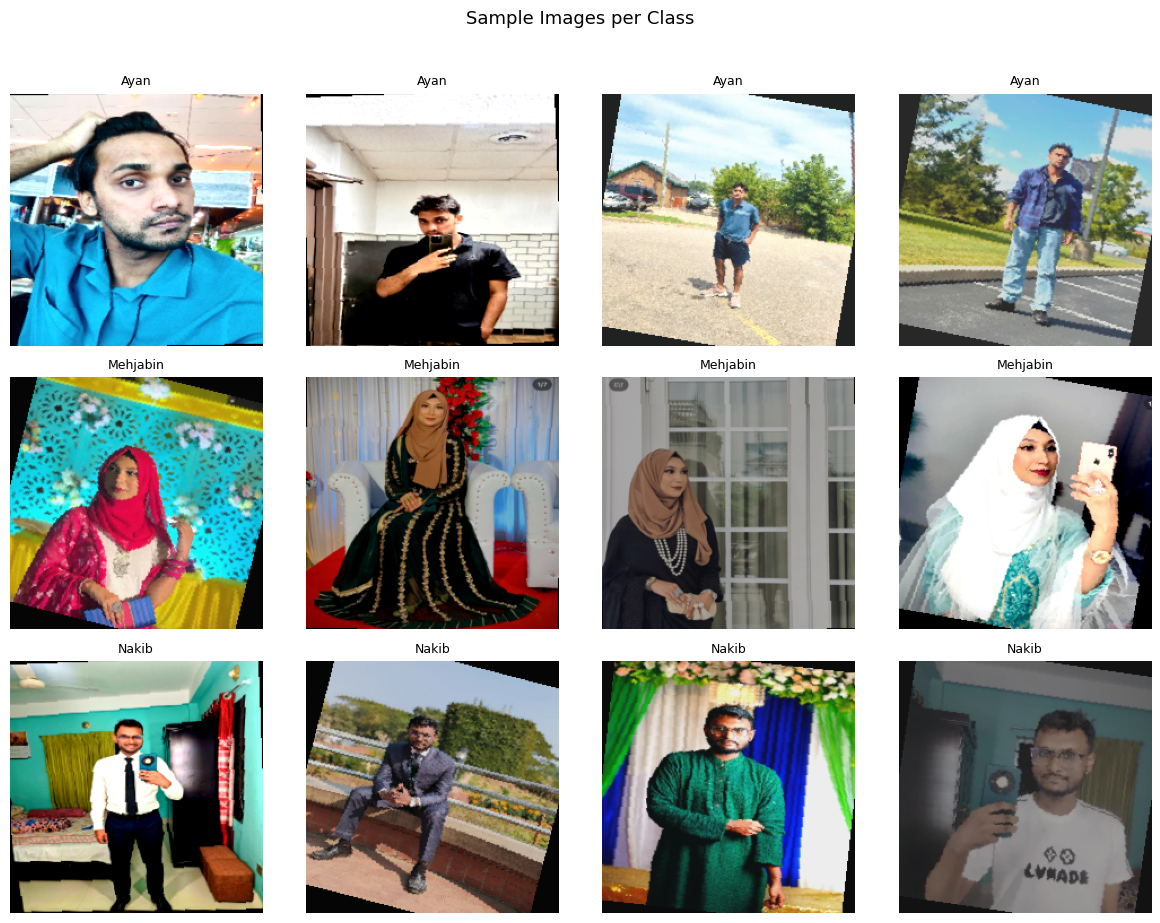

In [173]:
# ── Visualise Sample Images ───────────────────────────────────────────────────
def denorm(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(_mean).view(3, 1, 1)
    std  = torch.tensor(_std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

n_per_class = 4
fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(12, 3 * NUM_CLASSES))

counts = {i: 0 for i in range(NUM_CLASSES)}
for img, label in full_dataset:
    if counts[label] < n_per_class:
        axes[label, counts[label]].imshow(denorm(img).permute(1, 2, 0))
        axes[label, counts[label]].set_title(CLASS_NAMES[label], fontsize=9)
        axes[label, counts[label]].axis("off")
        counts[label] += 1
    if all(v == n_per_class for v in counts.values()):
        break

plt.suptitle("Sample Images per Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [174]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 16

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 3 | Val batches: 1


In [175]:
# ── Model ─────────────────────────────────────────────────────────────────────
from model import FaceRecognitionModel, DEVICE
from torchvision import models

model = FaceRecognitionModel(num_classes=NUM_CLASSES).to(DEVICE)

# Load pretrained weights into backbone
_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.backbone.load_state_dict(
    torch.nn.Sequential(*list(_resnet.children())[:-1]).state_dict()
)

# Freeze early layers, unfreeze layer4 + head so it learns faces
for param in model.backbone.parameters():
    param.requires_grad = False
for param in model.backbone[-2:].parameters():   # unfreeze layer4 + avgpool
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 8,525,827 / 11,308,611


In [176]:
# ── Training Setup ────────────────────────────────────────────────────────────
EPOCHS = 30

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {"params": model.backbone[-2:].parameters(), "lr": 1e-4},  # fine-tune backbone slowly
    {"params": model.head.parameters(),           "lr": 1e-3},  # train head faster
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Epochs: {EPOCHS}")

Epochs: 30


In [177]:
# ── Training Loop ─────────────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc, best_weights = 0.0, None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_acc:
        best_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

model.load_state_dict(best_weights)
print(f"\nBest val accuracy: {best_acc:.4f}")

Epoch 01/30  train_loss=1.0064  train_acc=0.3611  val_loss=1.3922  val_acc=0.4444
Epoch 02/30  train_loss=0.9404  train_acc=0.5278  val_loss=1.5399  val_acc=0.3333
Epoch 03/30  train_loss=0.7777  train_acc=0.5278  val_loss=1.5494  val_acc=0.3333
Epoch 04/30  train_loss=0.5887  train_acc=0.6667  val_loss=0.9948  val_acc=0.5556
Epoch 05/30  train_loss=0.4645  train_acc=0.7778  val_loss=0.7718  val_acc=0.5556
Epoch 06/30  train_loss=0.3646  train_acc=0.8889  val_loss=0.6350  val_acc=0.7778
Epoch 07/30  train_loss=0.2823  train_acc=0.9722  val_loss=0.7166  val_acc=0.5556
Epoch 08/30  train_loss=0.2208  train_acc=0.9444  val_loss=0.9399  val_acc=0.3333
Epoch 09/30  train_loss=0.3456  train_acc=0.8889  val_loss=0.8386  val_acc=0.5556
Epoch 10/30  train_loss=0.0914  train_acc=1.0000  val_loss=0.5827  val_acc=0.7778
Epoch 11/30  train_loss=0.1033  train_acc=1.0000  val_loss=0.5347  val_acc=0.7778
Epoch 12/30  train_loss=0.1258  train_acc=1.0000  val_loss=0.5332  val_acc=0.7778
Epoch 13/30  tra

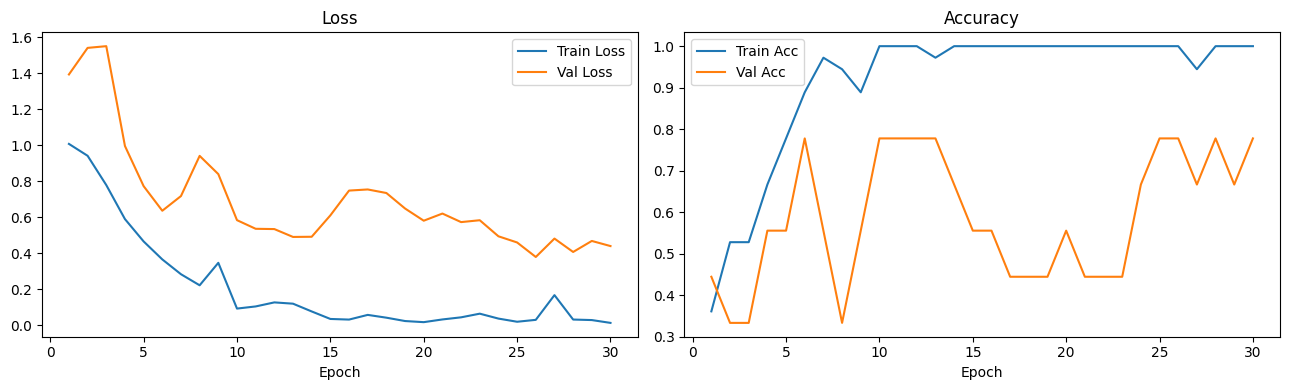

In [178]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="Train Acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val Acc")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

        Ayan       0.67      1.00      0.80         4
    Mehjabin       0.00      0.00      0.00         2
       Nakib       1.00      1.00      1.00         3

    accuracy                           0.78         9
   macro avg       0.56      0.67      0.60         9
weighted avg       0.63      0.78      0.69         9



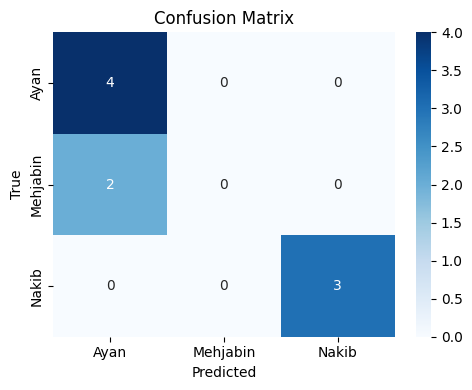

In [179]:
# ── Confusion Matrix & Per-Class Accuracy ────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

labels_range = list(range(NUM_CLASSES))
cm = confusion_matrix(all_labels, all_preds, labels=labels_range)
print(classification_report(all_labels, all_preds, labels=labels_range, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [180]:
# ── Save Model ────────────────────────────────────────────────────────────────
SAVE_PATH = Path("face_dl_model.pth")
torch.save({
    "model_state": model.state_dict(),
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
}, SAVE_PATH)
print(f"Model saved → {SAVE_PATH}")

Model saved → face_dl_model.pth
